<a href="https://colab.research.google.com/github/Fedyatch/DB2025/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_3_%D0%A7%D0%B0%D1%83%D1%81%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Написание функций для работы с sqlite с использованием python

In [1]:
%load_ext sql
%sql sqlite:///base.db

In [2]:
import sqlite3
connection = sqlite3.connect('base.db')

In [3]:
#список стран
countries = ["Afghanistan", "Albania", "Algeria", "Andorra", "Angola", "Anguilla", "Argentina", "Armenia", "Aruba", "Australia", "Austria", "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh",
             "Barbados", "Belarus", "Belgium", "Belize", "Benin", "Bermuda", "Bhutan", "Bolivia", "Bosnia and Herzegovina", "Botswana", "Brazil", "Bulgaria", "Burkina Faso", "Burundi", "Cambodia",
             "Cameroon", "Canada", "Central African Republic", "Chad", "Chile", "China", "Colombia", "Comoros", "Congo", "Costa Rica", "Cote d'Ivoire", "Croatia", "Cuba", "Cyprus", "Czech Republic",
             "Denmark", "Djibouti", "Dominica", "Dominican Republic", "Ecuador", "Egypt", "Eritrea", "Estonia", "Ethiopia", "Fiji", "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany", "Ghana",
             "Greece", "Greenland", "Grenada", "Guadeloupe", "Guam", "Guatemala", "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras", "Hong Kong", "Hungary", "Iceland", "India", "Indonesia", "Iran",
             "Iraq", "Ireland", "Isle of Man", "Israel", "Italy", "Jamaica", "Japan", "Jersey", "Jordan", "Kazakhstan", "Kenya", "Kiribati", "Kuwait", "Latvia", "Lebanon", "Lesotho", "Liberia", "Lithuania",
             "Luxembourg", "Macao", "Macedonia", "Madagascar", "Malawi", "Malaysia", "Maldives", "Mali", "Malta", "Martinique", "Mauritania", "Mauritius", "Mayotte", "Mexico", "Micronesia", "Moldova",
             "Monaco", "Mongolia", "Montenegro", "Montserrat", "Morocco", "Mozambique", "Myanmar", "Namibia", "Nauru", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger", "Nigeria", "Norway", "Oman",
             "Pakistan", "Palau", "Palestinian Territory", "Panama", "Papua New Guinea", "Paraguay", "Peru", "Philippines", "Poland", "Portugal", "Puerto Rico", "Qatar", "Republic of Korea", "Romania",
             "Russian Federation", "Rwanda", "Saudi Arabia", "Senegal", "Serbia", "Singapore", "Slovakia", "Slovenia", "Solomon Islands", "South Africa", "Spain", "Sudan", "Swaziland", "Sweden", "Switzerland",
             "Syrian Arab Republic", "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tokelau", "Tonga", "Tunisia", "Turkey", "Turkmenistan", "Tuvalu", "Uganda", "Ukraine", "United Arab Emirates",
             "United Kingdom", "United States of America", "Uruguay", "Uzbekistan", "Vanuatu", "Venezuela", "Vietnam", "Yemen", "Zambia", "Zimbabwe"]

Лабораторная посвящена базе данных, связанной со спортивными командами. Схема расположена на картинке ниже.

## Схема
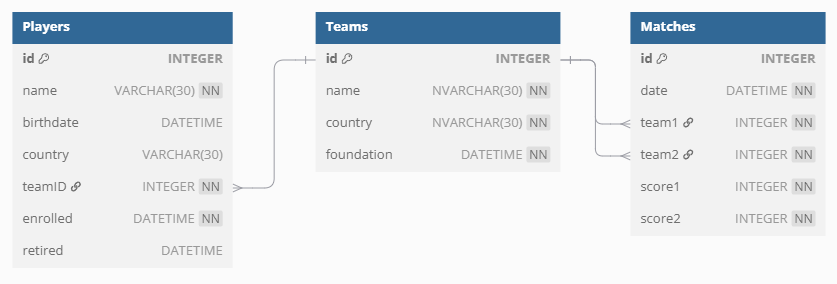

Foundation - дата основания

**Имя команды сделать unique**

# Задание 1
Реализовать таблицы со связями по схеме выше. Добавьте несколько команд и матчей между ними (через INSERT).

In [11]:
%%sql
Pragma foreign_keys = on;

DROP TABLE IF EXISTS Matches;
DROP TABLE IF EXISTS Players;
DROP TABLE IF EXISTS Teams;

CREATE TABLE Teams(
  team_id integer NOT NULL Primary key,
  team_name varchar(30) NOT NULL UNIQUE,
  country varchar(30) NOT NULL,
  foundation datetime NOT NULL
);

CREATE TABLE Players(
  player_id integer NOT NULL Primary key,
  player_name varchar(30) NOT NULL,
  player_birthdate datetime,
  country varchar(30),
  team_id integer NOT NULL,
  enrolled datetime NOT NULL,
  retired datetime,
  FOREIGN KEY (team_id) REFERENCES Teams(team_id)
);

CREATE TABLE Matches(
  match_id integer NOT NULL Primary key,
  match_date datetime NOT NULL,
  team1_id integer NOT NULL,
  team2_id integer NOT NULL,
  score1 integer NOT NULL,
  score2 integer NOT NULL,
  FOREIGN KEY (team1_id) REFERENCES Teams(team_id),
  FOREIGN KEY (team2_id) REFERENCES Teams(team_id)
);


 * sqlite:///base.db
Done.
Done.
Done.
Done.
Done.
Done.
Done.


[]

In [13]:
%%sql

INSERT INTO Teams (team_name, country, foundation)
VALUES
  ('Liverpool', 'England', '1892-06-03'),
  ('FC Barcelona', 'Spain', '1899-11-29'),
  ('Leicester City', 'England', '1884-01-01');

INSERT INTO Players (player_name, player_birthdate, country, team_id, enrolled, retired)
VALUES
  ('Mohamed Salah', '1992-06-15', 'Egypt', 1, '2023-07-01', NULL),
  ('Virgil van Dijk', '1991-07-08', 'Netherlands', 1, '2023-07-01', NULL),
  ('Robert Lewandowski', '1988-08-21', 'Poland', 2, '2023-07-01', NULL),
  ('Frenkie de Jong', '1997-05-12', 'Netherlands', 2, '2023-07-01', NULL),
  ('Jamie Vardy', '1987-01-11', 'England', 3, '2023-07-01', NULL),
  ('Kelechi Iheanacho', '1996-10-03', 'Nigeria', 3, '2023-07-01', NULL);

INSERT INTO Matches (match_date, team1_id, team2_id, score1, score2)
VALUES
  ('2024-03-10', 1, 2, 3, 1),
  ('2024-03-15', 2, 3, 1, 1),
  ('2024-03-20', 1, 3, 0, 1);

 * sqlite:///base.db
3 rows affected.
6 rows affected.
3 rows affected.


[]

# Задание 2

Написать функцию, осуществляющую добавление нового игрока в таблицу игроков.

На входе имя, дата рождения, страна, **имя команды**, дата перехода в команду, дата увольнения (необязательный параметр). Предусмотреть различные ошибки (такие как неверное название команды (игрока нельзя добавить, если его команды нет в таблице команд), возраст < 0 и т.п.)

После написания функции необходимо добавить несколько игроков.

In [14]:
import sqlite3
connection = sqlite3.connect('base.db')

In [20]:
import sqlite3
from datetime import datetime

def add_player(name, birthdate, country, team_name, enrolled, retired=None):
    # 1. Проверяем, существует ли команда
    cur = connection.cursor()
    cur.execute("SELECT team_id FROM Teams WHERE team_name = ?", (team_name,))
    try:
        team_id = cur.fetchone()[0]
    except:
        print("Ошибка: команда не найдена")
        return 0                     # аналог return 0 в check_client

    # 2. Проверяем, нет ли уже игрока с таким именем
    cur.execute("SELECT player_id FROM Players WHERE player_name = ?", (name,))
    if cur.fetchone() is not None:
        print("Ошибка: игрок с таким именем уже существует")
        return 0

    # 3. Проверки дат
    today_str = datetime.now().strftime("%Y-%m-%d")
    if birthdate > today_str:
        print("Ошибка: дата рождения в будущем")
        return -1
    if birthdate > enrolled:
        print("Ошибка: игрок не мог быть нанят до рождения")
        return -1
    if retired is not None and retired < enrolled:
        print("Ошибка: дата увольнения раньше даты найма")
        return -1

    # 4. Вставка записи
    cur.execute('''
        INSERT INTO Players (player_name, player_birthdate, country, team_id, enrolled, retired)
        VALUES (?, ?, ?, ?, ?, ?)
    ''', (name, birthdate, country, team_id, enrolled, retired))
    connection.commit()

    # 5. Получаем идентификатор нового игрока и возвращаем его
    player_id = cur.lastrowid
    print(f"Игрок '{name}' добавлен, id = {player_id}")
    return player_id

In [24]:
# Успешное добавление (без указания connection)
add_player('Erling Haaland', '2000-07-21', 'Norway', 'Liverpool', '2024-01-01')

# С указанием даты увольнения (последний параметр опционален)
add_player('Karim Benzema', '1987-12-19', 'France', 'FC Barcelona', '2022-07-01', retired='2023-06-01')

# Ошибка: команда не найдена
add_player('Lionel Messi', '1987-06-24', 'Argentina', 'Inter Miami', '2023-07-01')

Игрок 'Erling Haaland' добавлен, id = 7
Игрок 'Karim Benzema' добавлен, id = 8
Ошибка: команда не найдена


0

# Задание 3
Написать функцию player_stat, которая получает на вход имя игрока и выдает количество побед, ничей и поражений этого игрока (учитывать, что до и после найма игрока успехи его команды не учитываются).
Вывести статистику по игрокам.

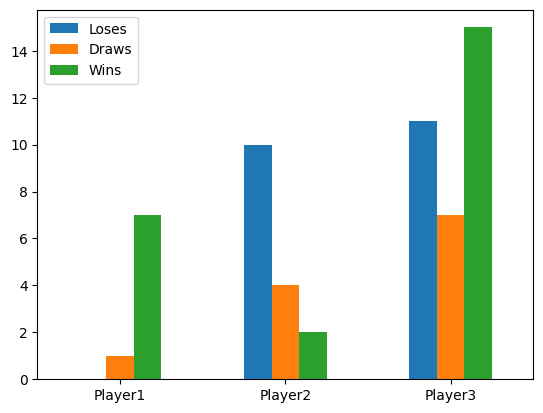

In [26]:
#Пример статистики
import matplotlib.pyplot as plt
import pandas as pd

players = ['Player1','Player2','Player3']
wins = [7, 2, 15]
draws = [1, 4, 7]
loses = [0, 10, 11]

df = pd.DataFrame({'Loses': loses, 'Draws': draws, 'Wins': wins}, index=players)
ax = df.plot.bar(rot=0)

In [17]:
import sqlite3

def player_stat(player_name):
    cur = connection.cursor()

    # 1. Проверяем, существует ли игрок с таким именем
    cur.execute("SELECT player_id FROM Players WHERE player_name = ?", (player_name,))
    if cur.fetchone() is None:
        print(f"Ошибка: игрок '{player_name}' не найден")
        return None

    # 2. SQL-запрос для подсчёта побед/ничьих/поражений
    query = """
    SELECT
      SUM(
        CASE
          WHEN (m.team1_id = p.team_id AND m.score1 > m.score2)
            OR (m.team2_id = p.team_id AND m.score2 > m.score1)
          THEN 1 ELSE 0
        END
      ) AS wins,
      SUM(
        CASE WHEN m.score1 = m.score2 THEN 1 ELSE 0 END
      ) AS draws,
      SUM(
        CASE
          WHEN (m.team1_id = p.team_id AND m.score1 < m.score2)
            OR (m.team2_id = p.team_id AND m.score2 < m.score1)
          THEN 1 ELSE 0
        END
      ) AS losses
    FROM Players p
    JOIN Matches m
      ON (m.team1_id = p.team_id OR m.team2_id = p.team_id)
      AND m.match_date >= p.enrolled
      AND (p.retired IS NULL OR m.match_date <= p.retired)
    WHERE p.player_name = ?
    GROUP BY p.player_id;
    """

    cur.execute(query, (player_name,))
    row = cur.fetchone()

    # 3. Если матчей в периоде не было – вернём нули
    if row is None:
        return {'wins': 0, 'draws': 0, 'losses': 0}

    wins, draws, losses = row
    return {
        'wins': wins or 0,
        'draws': draws or 0,
        'losses': losses or 0
    }

In [30]:
%%sql
INSERT INTO Matches (match_date, team1_id, team2_id, score1, score2)
VALUES
  ('2024-03-25', 1, 2, 2, 2),   -- Liverpool vs Barcelona 2:2
  ('2024-03-30', 2, 1, 1, 3),   -- Barcelona vs Liverpool 1:3
  ('2024-04-05', 1, 3, 2, 0),   -- Liverpool vs Leicester 2:0
  ('2024-04-10', 3, 1, 1, 2),   -- Leicester vs Liverpool 1:2
  ('2024-04-15', 2, 3, 0, 0),   -- Barcelona vs Leicester 0:0
  ('2024-04-20', 3, 2, 2, 1);   -- Leicester vs Barcelona 2:1

 * sqlite:///base.db
6 rows affected.


[]

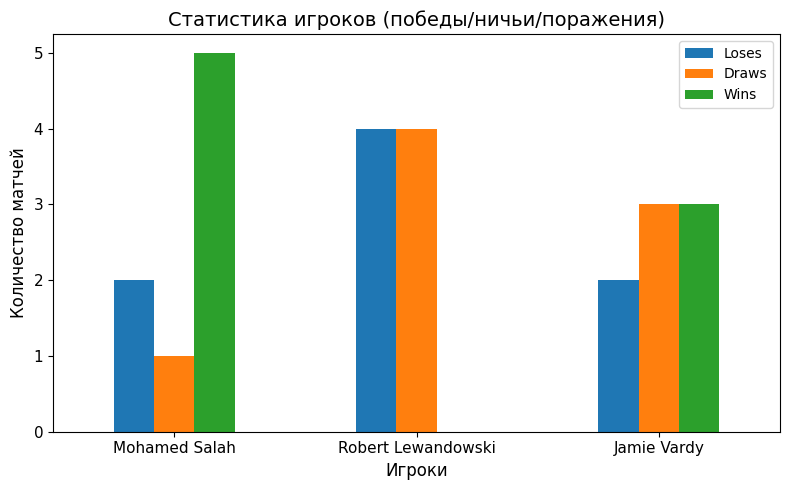

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

players = ['Mohamed Salah', 'Robert Lewandowski', 'Jamie Vardy']

stats = []
for name in players:
    res = player_stat(name)
    if res is None:
        res = {'wins': 0, 'draws': 0, 'losses': 0}
    stats.append(res)

df = pd.DataFrame(stats, index=players)
df = df[['losses', 'draws', 'wins']]
df.columns = ['Loses', 'Draws', 'Wins']

# Увеличиваем размер фигуры (ширина, высота в дюймах)
ax = df.plot.bar(rot=0, figsize=(8, 5))

# Дополнительно: можно подписать оси и увеличить шрифт меток
plt.xlabel("Игроки", fontsize=12)
plt.ylabel("Количество матчей", fontsize=12)
plt.title("Статистика игроков (победы/ничьи/поражения)", fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()  # чтобы подписи не обрезались
plt.show()